## Ejemplo de probabilidad Geométrica

Lanzamos una particula completamente al azar a una v=cte, dentro de un área de impacto cuadrada de lado L= 1m. ¿Cuál es la probabilidad de que caiga dentro de un círculo inscrito?

Primero diseñemos el esapcio muestral:

* El cuadrado:

$$
\Omega=[0,1] \times[0,1]
$$


Su área total:

$$
\operatorname{Area}(\Omega)=1
$$

Y recordemos entonces cualquier punto del cuadrado es igualmente probable.

Si consideramos el evento $\boldsymbol{A}$ : "El punto cae dentro del círculo", y que el círculo tiene:
- Centro en $(0.5,0.5)$
- Radio $r=0.5$

Su ecuación es:
$$
(x-a^`2 +(y-b)^2 \leq r^2
$$
$$
\Rightarrow (x-0.5)^2+(y-0.5)^2 \leq 0.5^2
$$

Por detinicion:

$$
P(A)=\frac{\text { Área del círculo }}{\text { Área del cuadrado }}
$$


Calculamos el área del círculo:

$$
\pi r^2=\pi(0.5)^2=\frac{\pi}{4}
$$


Entonces:

$$
P(A)=\frac{\pi}{4}
$$

$$\textbf{Tenemos el caso que una probabilidad contiene $\pi$ }$$

Y se sigue que:
$$
\pi = 4 P(A)
$$

P̂(dentro) = 0.785400
Exacta π/4 = 0.785398
Estimación de π = 4·P̂ = 3.141600


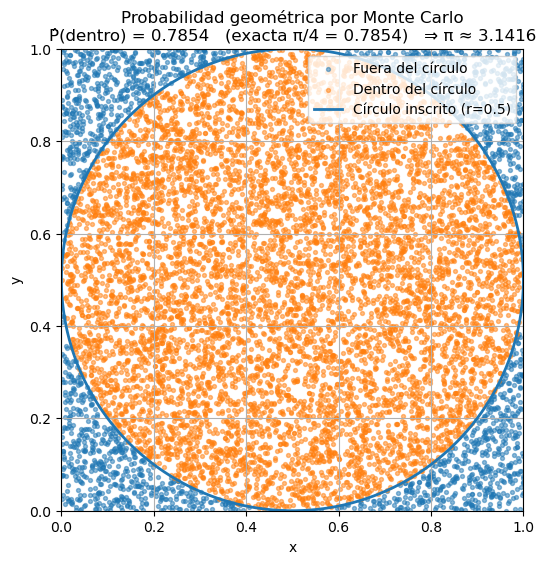

In [18]:
import numpy as np
import matplotlib.pyplot as plt

### pueden quitar la seed para reproducibilidad o cambiarla 
np.random.seed(3)      
N = 10000 # cambien N para ver convergencia

x = np.random.rand(N)
y = np.random.rand(N)

# Círculo:
inside = (x - 0.5)**2 + (y - 0.5)**2 <= 0.5**2

p_hat = inside.mean()
p_true = np.pi / 4
pi_est = 4 * p_hat

print(f"P̂(dentro) = {p_hat:.6f}")
print(f"Exacta π/4 = {p_true:.6f}")
print(f"Estimación de π = 4·P̂ = {pi_est:.6f}")

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(x[~inside], y[~inside], s=8, alpha=0.5, label="Fuera del círculo")
ax.scatter(x[inside],  y[inside],  s=8, alpha=0.5, label="Dentro del círculo")

theta = np.linspace(0, 2*np.pi, 400)
cx = 0.5 + 0.5*np.cos(theta)
cy = 0.5 + 0.5*np.sin(theta)
ax.plot(cx, cy, linewidth=2, label="Círculo inscrito (r=0.5)")

ax.set_aspect("equal", "box")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.grid(True)

ax.set_title(
    "Probabilidad geométrica por Monte Carlo\n"
    f"P̂(dentro) = {p_hat:.4f}   (exacta π/4 = {p_true:.4f})   ⇒ π ≈ {pi_est:.4f}"
)

ax.legend(loc="upper right")
plt.show()

### ¿Por qué es importante que $\pi = 4P(A)$?

La computadora como tal NO conoce $\pi$.

Solo genera muchos puntos aleatorios y va a contar cuántos caen dentro del círculo.

$$
P(A)=\frac{\# \text{casos favorables} }{\# \text{casos totales}}
$$

En el código :

$$
\hat{P}=\frac{\text { puntos dentro }}{\text { puntos totales }}
$$


Esto es una probabilidad experimental.

La idea clave es que si el experimento se repite muchas veces:

$$
\hat{P} \longrightarrow P(\text { dentro })
$$

¡Por la Ley de los Grandes Números!.

Pero sabemos que:

$$
P(\text { dentro })=\frac{\pi}{4}
$$


Entonces:

$$
\hat{P} \approx \frac{\pi}{4}
$$


En consecuencia:
$$
\pi \approx 4 \hat{P}
$$

$$\textbf{Podemos calcular $\pi$ usando probabilidad aleatoria.}$$



$$ Geometría = Probabilidad = Frecuencia experimental$$

### ¿Cuál es la probabilidad de caer EXACTAMENTE en el borde del círculo?

Recordando el axiomna de probabilidades continuas, la respuesta es
 $$ P(X=borde) =0
 $$
Porque el borde tiene área cero.

El “caer exactamente en el punto del borde” es como pedir que un dardo caiga exactamente en una marca infinitamente delgada.

Estamos a un paso de funciones de densidad de probabilidad, puesto que esto es similar a decir:

Si una partícula uniforme ocupa una región,

$$
P(A)=\int_A \rho(x, y) d A
$$

con densidad constante.